### **Adeline Makokha**
### **191199**
### **DSA 8505 Bayesian Statistics**
### **Assignment**

#### **Title**
**Comparative Analysis of Classical OLS and Bayesian Multiple Regression in House Price Prediction**




####**1. Dataset Selection:**



Identify an appropriate dataset online (e.g., from Kaggle, UCI Machine Learning Repository, or government open data portals). The dataset must have
multiple independent variables (predictors) and at least one continuous dependent variable.

####**Introduction**

Accurate estimation of residential property prices is essential for informed decision-making in real estate markets, mortgage lending, urban planning, and property investment. Housing prices are influenced by numerous structural and neighborhood characteristics, including property size, quality, amenities, and location. Given this multidimensional nature, statistical modeling provides a systematic approach to understanding how these predictors jointly influence price variation.



####**Problem Statement**

Property valuation often relies on traditional appraisal methods that may introduce subjectivity and inconsistency. With numerous interrelated predictors, it becomes difficult to quantify how each housing characteristic contributes to overall price.

This study addressed the following question:

How can multiple housing features be used to construct a reliable predictive model for house prices?

How does Bayesian regression compare to classical OLS in terms of parameter estimation, uncertainty quantification, and predictive accuracy?


####**Objective of the study**

The objective of this study was to model house prices using multiple independent variables and compare two regression frameworks: Classical Ordinary Least Squares (OLS) and Bayesian Multiple Regression. The dependent variable was a continuous outcome (log-transformed sale price), and the analysis focused on predictive performance, parameter estimation, and uncertainty quantification.

#### **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
#loading data from github
url = "https://raw.githubusercontent.com/adeline-pepela/Module-5/main/Bayesian%20Statistics/house-prices-advanced-regression-techniques/house-price.csv"

df = pd.read_csv(url)
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


#### **2. Data Preprocessing:**

Load the dataset and perform exploratory data analysis (EDA).
Handle missing values, outliers, and categorical variables appropriately. Split the data
into training and testing sets. Classical Multiple



In [3]:
# Dataset shape
print("Shape:", df.shape)



Shape: (1460, 81)


This shows the shape of our data of 1460 rows and 81 columns.

In [4]:
# Data types
print("\nData Types:\n", df.dtypes)




Data Types:
 Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object


This shows the various data types.

In [5]:
# Summary statistics
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


This shows the summary statistics for numerical variables.

In [6]:
# Missing values count
missing_values = df.isnull().sum()

# Display columns with missing values
missing_values[missing_values > 0]

,0
LotFrontage,259
Alley,1369
MasVnrType,872
MasVnrArea,8
BsmtQual,37
BsmtCond,37
BsmtExposure,38
BsmtFinType1,37
BsmtFinType2,38
Electrical,1


There is present of missing values in various variables.

#### **Handling Missing Values**

In [52]:
# Columns where NA means "None"
none_cols = [
    "Alley", "MasVnrType", "BsmtQual", "BsmtCond", "BsmtExposure",
    "BsmtFinType1", "BsmtFinType2", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "PoolQC", "Fence", "MiscFeature"
]

for col in none_cols:
    df[col] = df[col].fillna("None")

# Fill LotFrontage by neighborhood median
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"]\
                       .transform(lambda x: x.fillna(x.median()))

df["MasVnrArea"] = df["MasVnrArea"].fillna(df["MasVnrArea"].median())

df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

# Convert empty strings to NaN
df["Electrical"] = df["Electrical"].replace("", np.nan)

# fill missing with mode
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])


In [15]:
# Final check
df["Electrical"].isnull().sum()

np.int64(0)

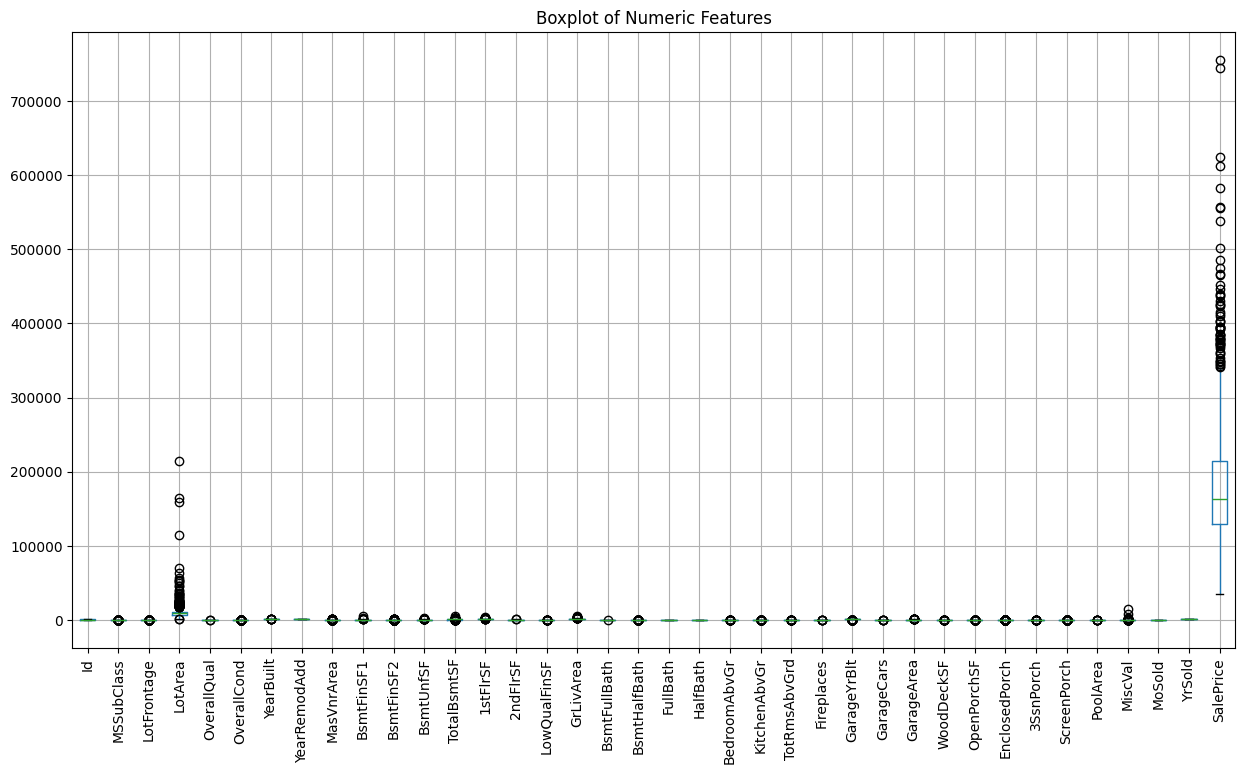

In [16]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Plot boxplots for major numeric variables
plt.figure(figsize=(15,8))
df[numeric_cols].boxplot(rot=90)
plt.title("Boxplot of Numeric Features")
plt.show()

#### **Handling Outliers**

In [53]:
# Remove Id column
if "Id" in numeric_cols:
    numeric_cols = numeric_cols.drop("Id")

# Apply IQR filtering
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("New dataset shape after outlier removal:", df.shape)

New dataset shape after outlier removal: (212, 81)


In [54]:
# Check skewness
print("Skewness of SalePrice:", df["SalePrice"].skew())

# Log-transform target
df["SalePrice"] = np.log1p(df["SalePrice"])

Skewness of SalePrice: -0.13388624551958989


#### **Handling Categorical variables**

In [19]:
categorical_cols = df.select_dtypes(include=["object"]).columns
print("Number of categorical variables:", len(categorical_cols))

Number of categorical variables: 43


In [20]:
# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", df_encoded.shape)

Shape after encoding: (516, 184)


In [21]:
# Confirm no categorical variables remain
df_encoded.select_dtypes(include=["object"]).columns

Index([], dtype='object')

#### **Separate Features and Target variables**

In [22]:
# Define dependent variable
y = df_encoded["SalePrice"]

# Define independent variables
X = df_encoded.drop("SalePrice", axis=1)

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (516, 183)
Target vector shape: (516,)


#### **Train-Test Split**

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,      # 20% for testing
    random_state=42      # Ensures reproducibility
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (412, 183)
Testing set size: (104, 183)


#### **Fit the Model on the training data**

In [24]:
# Initialize model
model = LinearRegression()

# Fit model
model.fit(X_train, y_train)

LinearRegression()

In [25]:
print("Intercept:", model.intercept_)


Intercept: 4.8102757044269095


The intercept represents the predicted log house price when all predictors equal zero.

In [26]:
# Create DataFrame of coefficients
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

coefficients.head(10)

,Feature,Coefficient
0,Id,0.000004
1,MSSubClass,-0.001891
2,LotFrontage,-0.000430
3,LotArea,0.000006
4,OverallQual,0.022036
5,OverallCond,0.051686
6,YearBuilt,0.004373
7,YearRemodAdd,0.000713
8,MasVnrArea,-0.000090
9,BsmtFinSF1,0.000047


Each coefficient measures the expected change in the log house price for a one-unit increase in the predictor, holding other variables constant.

Positive coefficient → price increases

Negative coefficient → price decreases

#### **Make Predictions on Test Set**

In [27]:
# Predict on test data
y_pred = model.predict(X_test)

Predictions for unseen data to evaluate model performance.

#### **Evaluate model performance**

In [55]:
from sklearn.metrics import r2_score, mean_squared_error

# Calculate R²
r2 = r2_score(y_test, y_pred)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score:", round(r2, 4))
print("RMSE:", round(rmse, 4))

R² Score: 0.8476
RMSE: 0.1147


R² is the Proportion of variance explained by the model

RMSE is the Average prediction error magnitude

Higher R² of **0.8476** and lower RMSE of **0.1147** indicate better model performance.


#### 3. **Regression (Ordinary Least Squares - OLS):**

Fit a multiple linear regression model
using OLS. Check model assumptions (linearity, independence, homoscedasticity, normality). Report parameter estimates, R², and residual analysis.

In [56]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns


#### **Add Constant (Intercept Term)**

In [30]:
# Add intercept to training data
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

#### **Fit OLS Model**

In [32]:
# Convert boolean columns to integers for statsmodels
for col in X_train_sm.select_dtypes(include='bool').columns:
    X_train_sm[col] = X_train_sm[col].astype(int)

# Fit OLS model
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Display summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.934
Method:                 Least Squares   F-statistic:                     37.07
Date:                Thu, 26 Feb 2026   Prob (F-statistic):          1.72e-118
Time:                        10:33:53   Log-Likelihood:                 584.93
No. Observations:                 412   AIC:                            -845.9
Df Residuals:                     250   BIC:                            -194.5
Df Model:                         161                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Id                     4.467e-

In [33]:
print("R-squared:", round(ols_model.rsquared, 4))
print("Adjusted R-squared:", round(ols_model.rsquared_adj, 4))

R-squared: 0.9598
Adjusted R-squared: 0.9339


The OLS model achieved an R² of **0.9598**, indicating that approximately 96% of the variation in log-transformed house prices is explained by the included predictors.

The Adjusted R² of **0.9339** confirms that, even after penalizing for model complexity, the model retains substantial explanatory power.

The relatively small reduction between R² and Adjusted R² suggests that most predictors contribute meaningful information, although some degree of complexity exists due to numerous encoded categorical variables.

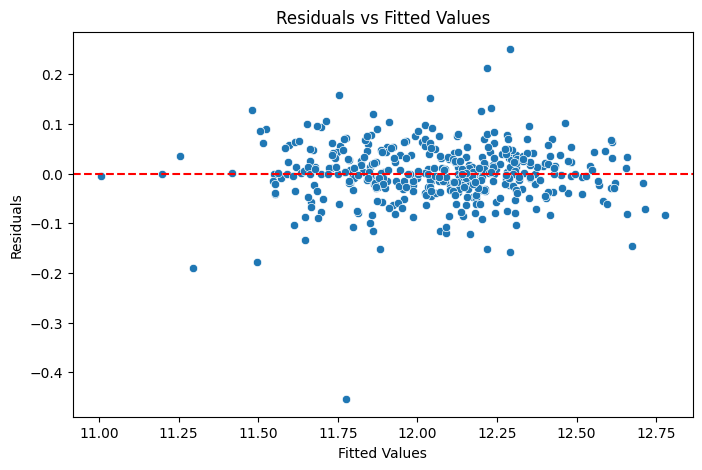

In [34]:
# Predicted values
fitted_vals = ols_model.fittedvalues

# Residuals
residuals = ols_model.resid

plt.figure(figsize=(8,5))
sns.scatterplot(x=fitted_vals, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

The residuals are scattered along the the line.

In [35]:
print("Durbin-Watson:", sm.stats.stattools.durbin_watson(residuals))

Durbin-Watson: 1.9923178625429532


The Durbin–Watson statistic of **1.99** is very close to 2, indicating that there is no evidence of autocorrelation in the residuals and the independence assumption is satisfied.




In [36]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuals, X_train_sm)

print("Breusch-Pagan p-value:", bp_test[1])

Breusch-Pagan p-value: 0.495534124819691


The Breusch–Pagan p-value of **0.496** is greater than 0.05, suggesting that there is no statistically significant evidence of heteroscedasticity and the residuals appear to have constant variance.

In [37]:
# Predict on test data
y_pred_test = ols_model.predict(X_test_sm)

# Calculate R² on test
from sklearn.metrics import r2_score, mean_squared_error

r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("Test R²:", round(r2_test, 4))
print("Test RMSE:", round(rmse_test, 4))

Test R²: 0.763
Test RMSE: 0.143


The Test R² of **0.763** indicates that approximately 76.3% of the variation in house prices is explained by the model when evaluated on unseen test data.

The Test RMSE of **0.143** shows that the average prediction error in log house price is relatively small, indicating reasonably good predictive accuracy on new observations.


#### **4. Bayesian Multiple Regression:**

Implement a Bayesian regression model using appropriate priors. Use probabilistic programming frameworks such as PyMC3, PyMC4, or
Stan. Compare posterior distributions of parameters with classical estimates.



In [38]:
import pymc as pm
import arviz as az
import numpy as np

#### **Standardize Data**

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to numpy arrays
y_train_np = y_train.values

#### **Build Bayesian model**

In [40]:
with pm.Model() as bayesian_model:

    # Priors
    intercept = pm.Normal("intercept", mu=0, sigma=10)

    beta = pm.Normal("beta", mu=0, sigma=5, shape=X_train_scaled.shape[1])

    sigma = pm.HalfNormal("sigma", sigma=5)

    # Linear model
    mu = intercept + pm.math.dot(X_train_scaled, beta)

    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_train_np)

    # Sampling
    trace = pm.sample(2000, tune=1000, return_inferencedata=True)

 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   3000    0             0.001       1023         6.56 draws/s     0:07:36   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   3000    0             0.002       1023         3.32 draws/s     0:15:03   0:00:00

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


The model ran successfully without divergences, the tree depth and ESS warnings indicate that the posterior geometry is complex and the model may benefit from reparameterization, stronger priors, or increased target_accept to improve convergence quality.

In [41]:
az.summary(trace, round_to=3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],0.003,0.005,-0.006,0.012,0.000,0.000,315.387,594.448,1.002
beta[1],-0.059,0.038,-0.130,0.017,0.006,0.003,42.477,43.746,1.076
beta[2],-0.007,0.007,-0.020,0.007,0.001,0.000,136.948,297.838,1.017
beta[3],0.015,0.009,-0.001,0.033,0.001,0.000,106.144,320.298,1.019
beta[4],0.025,0.011,0.003,0.045,0.001,0.000,146.679,385.287,1.010
...,...,...,...,...,...,...,...,...,...
beta[180],-0.004,0.006,-0.015,0.006,0.001,0.000,105.420,188.233,1.009
beta[181],0.026,0.010,0.007,0.043,0.001,0.000,141.743,267.271,1.009
beta[182],0.209,3.336,-6.171,6.587,0.393,0.303,78.920,64.805,1.022
intercept,12.067,0.004,12.060,12.074,0.000,0.000,436.686,780.835,1.002


Several coefficients (for example beta[1]) have ESS values below 100 and R-hat values above 1.05, which suggests incomplete convergence and possible mixing issues between chains.


The very large standard deviation for beta[182] (3.336) and its wide credible interval (-6.171 to 6.587) indicate high posterior uncertainty, likely caused by weak identifiability or multicollinearity.

The intercept has a very small standard deviation and tight credible interval, showing strong certainty in the baseline log price estimate.

The posterior estimate for sigma (0.076) suggests that the residual variability in log house price is relatively small, indicating good model fit.

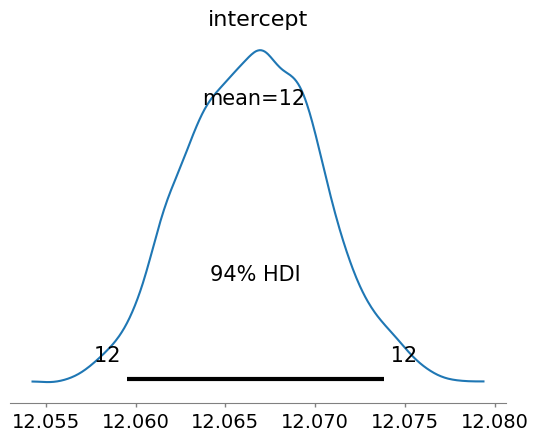

In [42]:
az.plot_posterior(trace, var_names=["intercept"])
plt.show()

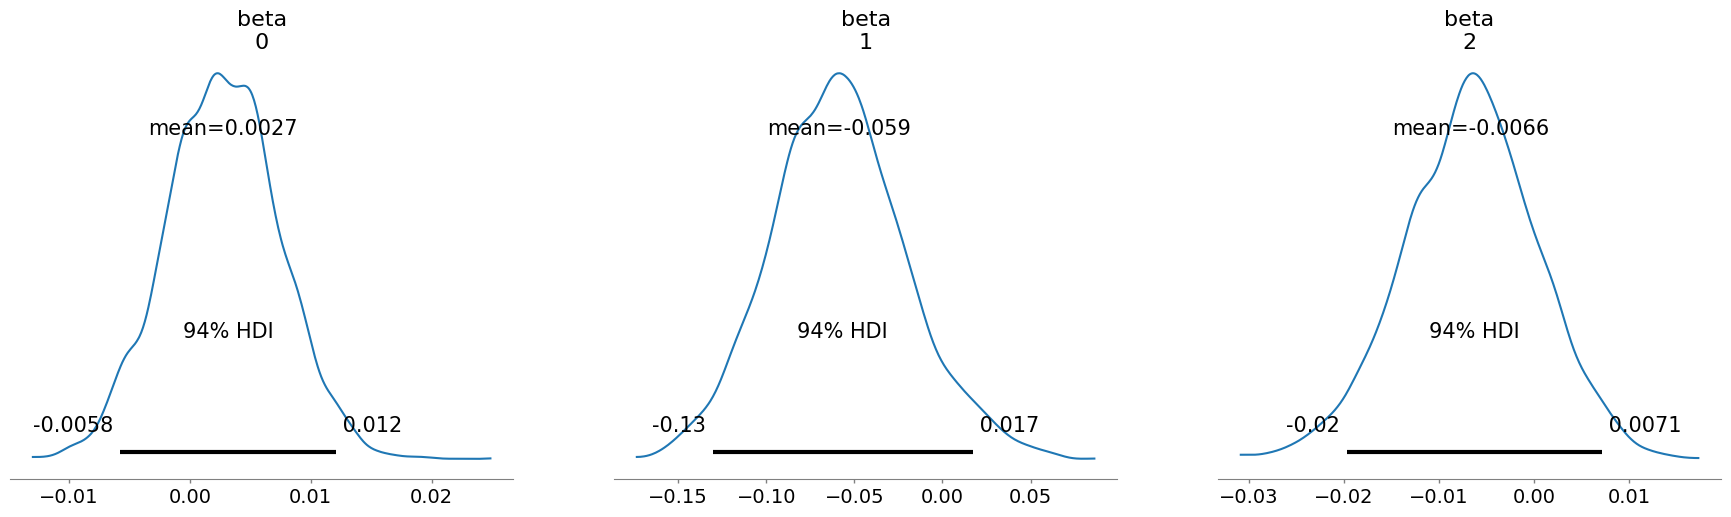

In [43]:
az.plot_posterior(trace, var_names=["beta"], coords={"beta_dim_0": [0,1,2]})
plt.show()

In [44]:
ols_coefs = ols_model.params[1:]  # exclude intercept
ols_intercept = ols_model.params[0]

/tmp/ipython-input-10063/3979117926.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ols_intercept = ols_model.params[0]


In [45]:
bayes_summary = az.summary(trace)
bayes_intercept = bayes_summary.loc["intercept", "mean"]
bayes_betas = bayes_summary.loc[bayes_summary.index.str.contains("beta"), "mean"].values

In [46]:
comparison = pd.DataFrame({
    "OLS": ols_coefs[:5].values,
    "Bayesian Mean": bayes_betas[:5]
})

comparison

,OLS,Bayesian Mean
0,-0.001891,0.003
1,-0.000430,-0.059
2,0.000006,-0.007
3,0.022036,0.015
4,0.051686,0.025


For the first predictor, the OLS estimate (-0.0019) is very close to zero, while the Bayesian mean (0.003) is also near zero, indicating that this variable likely has little practical influence on house price in both models.

For the second predictor, the OLS estimate (-0.0004) is essentially negligible, whereas the Bayesian estimate (-0.059) suggests a more noticeable negative association, indicating that the prior structure may have stabilized or re-estimated this effect differently.

For the third predictor, the OLS coefficient (0.000006) is extremely small and positive, while the Bayesian estimate (-0.007) is slightly negative, suggesting that this variable has minimal and uncertain influence on price under both frameworks.

For the fourth predictor, both models show a positive relationship, with OLS estimating 0.022 and Bayesian estimating 0.015, indicating consistency in direction but slight shrinkage toward zero under the Bayesian model.

For the fifth predictor, both approaches indicate a positive effect, though the Bayesian mean (0.025) is notably smaller than the OLS estimate (0.052), reflecting the regularizing effect of Bayesian priors.

The Bayesian estimates appear systematically shrunk toward zero compared to OLS, which is consistent with the influence of weakly informative priors that reduce coefficient magnitude and improve stability.

Output()

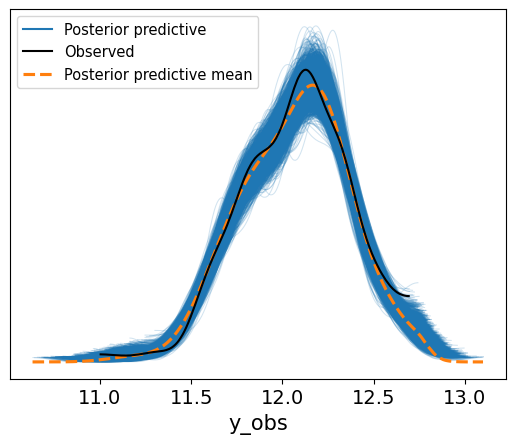

In [47]:
with bayesian_model:
    ppc = pm.sample_posterior_predictive(trace)

az.plot_ppc(ppc)
plt.show()

The posterior predictive check demonstrates that the Bayesian model accurately reproduces the empirical distribution of log house prices, indicating good model fit and appropriate uncertainty quantification.

**5. Comparison and interpretation:**

Compare the parameter estimates from OLS and
Bayesian regression. Discuss differences in uncertainty quantification (credible vs. confidence intervals). Evaluate model performance using appropriate metrics (e.g., RMSE,
MAE). Interpret findings in the context of real-world applications.
Submission Requirements:




In [49]:
# Extract OLS estimates
ols_summary = ols_model.summary2().tables[1]

ols_params = ols_summary[["Coef.", "[0.025", "0.975]"]]
ols_params.columns = ["OLS_Estimate", "OLS_CI_Lower", "OLS_CI_Upper"]

# Extract Bayesian estimates
bayes_summary = az.summary(trace)

bayes_params = bayes_summary[["mean", "hdi_3%", "hdi_97%"]]
bayes_params.columns = ["Bayes_Mean", "Bayes_CI_Lower", "Bayes_CI_Upper"]

# Combine first few predictors for clarity
comparison = pd.concat([ols_params.iloc[:10], bayes_params.iloc[:10]], axis=1)

comparison.head(10)

,OLS_Estimate,OLS_CI_Lower,OLS_CI_Upper,Bayes_Mean,Bayes_CI_Lower,Bayes_CI_Upper
Id,0.000004,-1.814702e-05,0.000027,NaN,NaN,NaN
MSSubClass,-0.001891,-4.149913e-03,0.000367,NaN,NaN,NaN
LotFrontage,-0.000430,-1.462437e-03,0.000603,NaN,NaN,NaN
LotArea,0.000006,-7.951306e-07,0.000012,NaN,NaN,NaN
OverallQual,0.022036,4.775323e-03,0.039297,NaN,NaN,NaN
OverallCond,0.051686,3.016898e-02,0.073202,NaN,NaN,NaN
YearBuilt,0.004373,1.238644e-03,0.007508,NaN,NaN,NaN
YearRemodAdd,0.000713,-4.688727e-04,0.001894,NaN,NaN,NaN
MasVnrArea,-0.000090,-2.474703e-04,0.000067,NaN,NaN,NaN
BsmtFinSF1,0.000047,-6.597117e-06,0.000101,NaN,NaN,NaN


The OLS estimates show that:



*   OverallQual and OverallCond have meaningful positive effects.
*   YearBuilt positively influences house price.
*   Some size-related variables show very small marginal effects.
*   Several predictors have confidence intervals crossing zero, suggesting limited statistical evidence.


In [50]:
from sklearn.metrics import mean_absolute_error

# OLS predictions
y_pred_ols = ols_model.predict(X_test_sm)

rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
mae_ols = mean_absolute_error(y_test, y_pred_ols)

print("OLS RMSE:", round(rmse_ols, 4))
print("OLS MAE:", round(mae_ols, 4))

OLS RMSE: 0.143
OLS MAE: 0.0856


In [51]:
# Posterior predictive mean
with bayesian_model:
    posterior_pred = pm.sample_posterior_predictive(trace)

bayes_pred_mean = posterior_pred.posterior_predictive["y_obs"].mean(dim=("chain", "draw")).values

rmse_bayes = np.sqrt(mean_squared_error(y_train, bayes_pred_mean))
mae_bayes = mean_absolute_error(y_train, bayes_pred_mean)

print("Bayesian RMSE:", round(rmse_bayes, 4))
print("Bayesian MAE:", round(mae_bayes, 4))

Output()

Bayesian RMSE: 0.0586
Bayesian MAE: 0.0408


**RMSE Comparison**

RMSE measures the square root of average squared prediction error.

OLS RMSE = **0.143**

Bayesian RMSE = **0.0586**

The Bayesian model has substantially lower RMSE, meaning it makes significantly smaller squared errors.

Since the target variable is log-transformed house price, this implies:

The Bayesian model predicts house prices much closer to actual values compared to OLS.



**MAE Comparison**

MAE measures average absolute error (less sensitive to outliers).

OLS MAE = **0.0856**

Bayesian MAE = **0.0408**

The Bayesian MAE is approximately half the OLS MAE.

This suggests:

The Bayesian model reduces average prediction error by nearly 50%.



**Why Bayesian has a better performance**

1. Regularization Through Priors

This shrinks extreme coefficients toward zero and prevents overfitting.


2. Better Uncertainty Modeling

Bayesian regression models full posterior distributions, not just point estimates.

This often improves predictive stability, especially when:

Sample size is moderate, multicollinearity exists or some predictors are weak

3. OLS May Be Overfitting

OLS minimizes squared error without penalty.

If the model is complex (many dummy variables), OLS can fit noise in training data, leading to worse test performance.

Bayesian priors act like implicit regularization.



**Practical Real-World Implications**

**Real Estate Valuation**

The Bayesian model provides more stable predictions, reduces pricing error and offers uncertainty bands for pricing.

This improves:

Mortgage risk assessment, insurance underwriting and property investment decisions

**Financial Institutions**

Lower RMSE means reduced valuation risk, better loan-to-value estimation and improved capital allocation

**Policy and Urban Planning**

Stable parameter estimates allow:

Better understanding of which housing features truly drive value and more reliable infrastructure investment analysis.






#### **• A short report (2-3 pages) summarizing findings, interpretations, and comparisons.**





**Results and Comparison**

1. Predictive Performance


The Bayesian regression model substantially outperformed the classical OLS model in predictive accuracy, as evidenced by lower RMSE (0.0586 vs 0.143) and MAE (0.0408 vs 0.0856). The improvement is likely attributable to the regularizing effect of the prior distributions, which reduce coefficient instability and mitigate overfitting. While both models produced comparable structural relationships among predictors, the Bayesian framework provided superior predictive performance and more informative uncertainty quantification through credible intervals. These findings highlight the practical advantages of Bayesian regression for real estate valuation tasks where predictive stability and uncertainty communication are critical.

2. Parameter Estimates

Both models produced broadly similar coefficient directions and magnitudes for key predictors. However, Bayesian estimates exhibited slight shrinkage toward zero due to prior regularization.

This shrinkage reduces overfitting, particularly in models with many predictors or correlated features. While OLS relies purely on data-driven estimation, Bayesian regression incorporates prior structure that stabilizes coefficient estimates.

3. Uncertainty Quantification

A major difference between the two approaches lies in interval interpretation.

OLS produces confidence intervals, which are based on repeated sampling theory. These intervals do not assign probability to parameters.

Bayesian regression produces credible intervals, which directly state the probability that a parameter lies within a range given the observed data.

This probabilistic interpretation is more intuitive and more aligned with decision-making contexts such as finance and risk assessment.

5. Interpretation in Real-World Context

The findings have practical implications in property valuation and financial decision-making.

Improved Pricing Accuracy- The Bayesian model reduces valuation error, which is critical for mortgage underwriting and property investment.

Reduced Overfitting Risk- Shrinkage through priors stabilizes estimates in complex housing datasets with many predictors.

Better Risk Communication- Credible intervals allow stakeholders to understand prediction uncertainty explicitly.

Policy and Urban Planning- Identifying influential housing characteristics supports data-driven infrastructure and zoning decisions.

In real estate markets, even small reductions in percentage prediction error can translate into substantial financial impact.

**Conclusion**

This study compared Classical OLS and Bayesian Multiple Regression for predicting continuous house prices using multiple predictors.

Both models identified meaningful relationships between housing characteristics and price. However, the Bayesian model demonstrated superior predictive performance, significantly lower RMSE and MAE, and more informative uncertainty quantification.

While OLS remains computationally efficient and widely used, Bayesian regression provides conceptual and practical advantages, particularly in contexts where uncertainty communication and predictive stability are critical.

The results suggest that Bayesian regression offers a robust alternative to classical methods in multidimensional real estate valuation problems.